In [1]:
import numpy as np
from matplotlib import pyplot as plt
import os
from matplotlib.colors import LightSource
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
n_qubits = 7

cwd = os.getcwd()
displaced_distances_folder = cwd+"/data/disp_dist/"
clifford_distances_folder = cwd+"/data/clif_dist/"
graphs_folder = cwd+"/data/graphs/"
min_deg, max_deg, avg_deg, min_rank, max_rank, avg_rank = np.genfromtxt(graphs_folder+str(n_qubits)+"_props.txt", delimiter=",", dtype = float, unpack = True)
disp_max_G_dist = np.genfromtxt(displaced_distances_folder+"max_G_q"+str(n_qubits)+".txt", usecols = 0, delimiter=",", dtype = float)
disp_max_R_dist = np.genfromtxt(displaced_distances_folder+"max_R_q"+str(n_qubits)+".txt", usecols = 0, delimiter=",", dtype = float)
clif_max_G_dist = np.genfromtxt(clifford_distances_folder+"max_G_q"+str(n_qubits)+".txt", usecols = 0, delimiter=",", dtype = float)
clif_max_R_dist = np.genfromtxt(clifford_distances_folder+"max_R_q"+str(n_qubits)+".txt", usecols = 0, delimiter=",", dtype = float)
graph_number = disp_max_G_dist.size

In [3]:
xlim = 0.5
ylim = 0.8

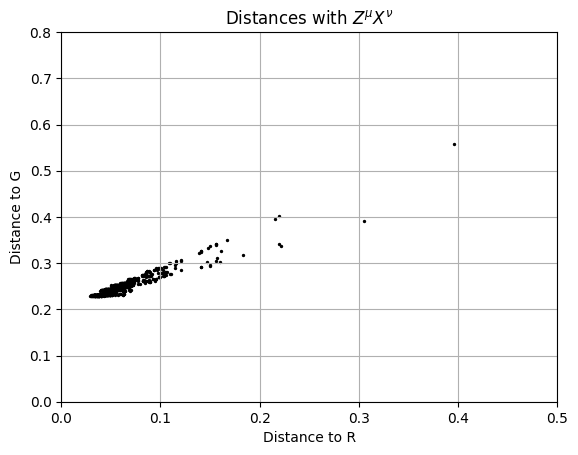

In [4]:
fig = plt.figure(6754)
ax = fig.subplots()
ax.set_title(r'Distances with $Z^\mu X^\nu$')
ax.scatter(np.sqrt(disp_max_R_dist), np.sqrt(disp_max_G_dist), 2, 'k')
ax.set_xlabel("Distance to R")
ax.set_ylabel("Distance to G")
ax.set_xlim(0,xlim)
ax.set_ylim(0,ylim)
ax.set_xticks(np.arange(0,xlim+0.1,step=0.1))
ax.set_yticks(np.arange(0,ylim+0.1,step=0.1))
ax.grid()

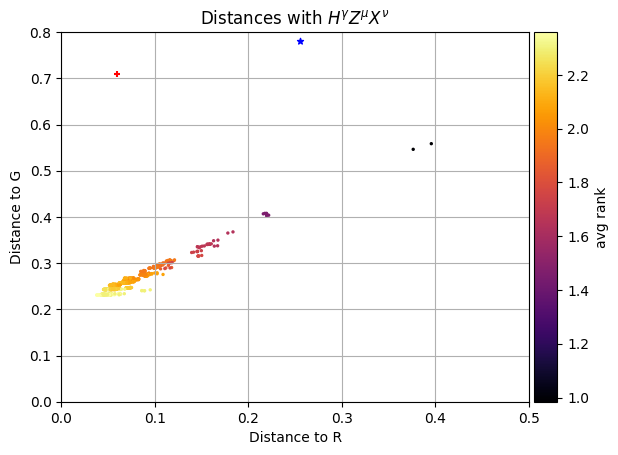

In [5]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances with $H^\gamma Z^\mu X^\nu$')
ax.scatter([0.06], [0.71], 20, 'r',marker="+")
ax.scatter([0.255], [0.78], 20, 'b',marker="*")
scatter_plot = ax.scatter(np.sqrt(clif_max_R_dist), np.sqrt(clif_max_G_dist), 2, c=avg_rank, cmap='inferno')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(scatter_plot, cax=cax, orientation='vertical', label=r'avg rank')
ax.set_xlabel("Distance to R")
ax.set_ylabel("Distance to G")
ax.set_xlim(0,xlim)
ax.set_ylim(0,ylim)
ax.set_xticks(np.arange(0,xlim+0.1,step=0.1))
ax.set_yticks(np.arange(0,ylim+0.1,step=0.1))
ax.grid()

In [6]:
n_qubits = 16
filename = "coherent_symQ_q"+str(n_qubits)+".txt"
symQfunc = np.genfromtxt("C:/dev/StabilizerStates/data/symQfuncs/"+filename, usecols = 0, delimiter=",", dtype = float)
symQfunc = np.reshape(symQfunc,(n_qubits+1,n_qubits+1,n_qubits+1))
_x, _y, _z = np.arange(0,n_qubits,1), np.arange(0,n_qubits,1), np.arange(0,n_qubits,1)
_xx, _yy, __zz = np.meshgrid(_x, _y, _z, indexing="ij")
x, y, z = _xx.ravel(), _yy.ravel(), __zz.ravel()

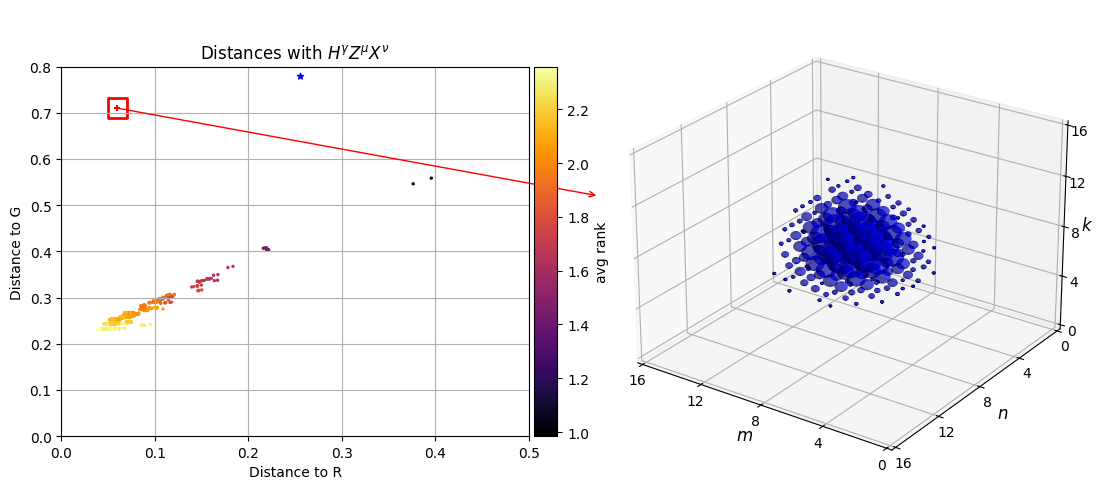

In [7]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances with $H^\gamma Z^\mu X^\nu$')
ax.scatter([0.06], [0.71], 20, 'r',marker="+")
ax3d = fig.add_axes([0.85, 0, 1, 1], projection='3d')
ax3d.set_xticks([])
ax3d.set_yticks([])
ax3d.set_zticks([])

light = LightSource(0,20)
ax3d.set_xlabel(r'$m$', size=12, labelpad=-5)
ax3d.set_ylabel(r'$n$', size=12, labelpad=-5)
ax3d.set_zlabel(r'$k$', size=12, labelpad=-11)
ax3d.set_xlim(0,n_qubits)
ax3d.set_ylim(0,n_qubits)
ax3d.set_zlim(0,n_qubits)
ax3d.tick_params(axis='both', size=10, pad=-3)
ax3d.set_xticks([0,4,8,12,16])
ax3d.set_yticks([0,4,8,12,16])
ax3d.set_zticks([0,4,8,12,16])
maxQ = np.max(symQfunc)

ax3d.view_init(25, 125)
# ax.text(16, 16, 20, "(b)", fontsize=12)

# Plot symmetric space outline
# verts = [(0, 0, 0), (n_qubits, n_qubits, 0), (0, n_qubits, n_qubits), (n_qubits, 0, n_qubits)]
# faces = [[0, 1, 2], [0, 2, 3], [0, 1, 3], [1, 2, 3]]
# poly3d = [[verts[vert_id] for vert_id in face] for face in faces]# draw vertex
# collection = Poly3DCollection(poly3d, edgecolors= 'k', facecolor= [0, 0, 0], linewidths=1, alpha=0.2)
# ax.add_collection3d(collection)

for (i,j,k) in zip(x,y,z):
    r = symQfunc[i,j,k] / maxQ
    if r > 0.1:
        u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:50j]
        s_x = r*np.cos(u)*np.sin(v)
        s_y = r*np.sin(u)*np.sin(v)
        s_z = r*np.cos(v)

        ax3d.plot_surface(s_x+i, s_y+j, s_z+k, color = 'b', alpha=0.5)

ax.annotate("",
            xy=(1.15, 0.65), xycoords='axes fraction',
            xytext=(0.06, 0.71), textcoords='data',
            arrowprops=dict(arrowstyle="->", color='red'))
ax.scatter([0.06], [0.71], s=200, facecolors='none', edgecolors='red', linewidths=2, marker="s")
ax.scatter([0.255], [0.78], 20, 'b',marker="*")
scatter_plot = ax.scatter(np.sqrt(clif_max_R_dist), np.sqrt(clif_max_G_dist), 2, c=avg_rank, cmap='inferno')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(scatter_plot, cax=cax, orientation='vertical', label=r'avg rank')
ax.set_xlabel("Distance to R")
ax.set_ylabel("Distance to G")
ax.set_xlim(0,xlim)
ax.set_ylim(0,ylim)
ax.set_xticks(np.arange(0,xlim+0.1,step=0.1))
ax.set_yticks(np.arange(0,ylim+0.1,step=0.1))
ax.grid()

In [31]:
n_qubits = 16
filename = "mc_q"+str(n_qubits)+".txt"
symQfunc = np.genfromtxt("C:/dev/StabilizerStates/data/symQfuncs/"+filename, usecols = 0, delimiter=",", dtype = float)
symQfunc = np.reshape(symQfunc,(n_qubits+1,n_qubits+1,n_qubits+1))
_x, _y, _z = np.arange(0,n_qubits,1), np.arange(0,n_qubits,1), np.arange(0,n_qubits,1)
_xx, _yy, __zz = np.meshgrid(_x, _y, _z, indexing="ij")
x, y, z = _xx.ravel(), _yy.ravel(), __zz.ravel()

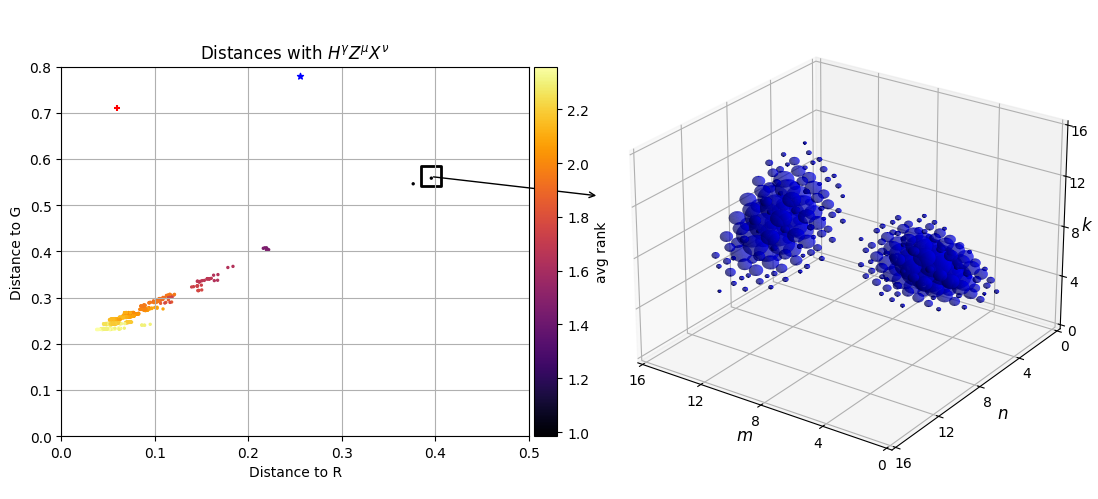

In [32]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances with $H^\gamma Z^\mu X^\nu$')
ax.scatter([0.06], [0.71], 20, 'r',marker="+")
ax3d = fig.add_axes([0.85, 0, 1, 1], projection='3d')
ax3d.set_xticks([])
ax3d.set_yticks([])
ax3d.set_zticks([])

light = LightSource(0,20)
ax3d.set_xlabel(r'$m$', size=12, labelpad=-5)
ax3d.set_ylabel(r'$n$', size=12, labelpad=-5)
ax3d.set_zlabel(r'$k$', size=12, labelpad=-11)
ax3d.set_xlim(0,n_qubits)
ax3d.set_ylim(0,n_qubits)
ax3d.set_zlim(0,n_qubits)
ax3d.tick_params(axis='both', size=10, pad=-3)
ax3d.set_xticks([0,4,8,12,16])
ax3d.set_yticks([0,4,8,12,16])
ax3d.set_zticks([0,4,8,12,16])
maxQ = np.max(symQfunc)

ax3d.view_init(25, 125)
# ax.text(16, 16, 20, "(b)", fontsize=12)

# Plot symmetric space outline
# verts = [(0, 0, 0), (n_qubits, n_qubits, 0), (0, n_qubits, n_qubits), (n_qubits, 0, n_qubits)]
# faces = [[0, 1, 2], [0, 2, 3], [0, 1, 3], [1, 2, 3]]
# poly3d = [[verts[vert_id] for vert_id in face] for face in faces]# draw vertex
# collection = Poly3DCollection(poly3d, edgecolors= 'k', facecolor= [0, 0, 0], linewidths=1, alpha=0.2)
# ax.add_collection3d(collection)

for (i,j,k) in zip(x,y,z):
    r = symQfunc[i,j,k] / maxQ
    if r > 0.1:
        u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:50j]
        s_x = r*np.cos(u)*np.sin(v)
        s_y = r*np.sin(u)*np.sin(v)
        s_z = r*np.cos(v)

        ax3d.plot_surface(s_x+i, s_y+j, s_z+k, color = 'b', alpha=0.5)

ax.scatter([0.395], [0.563], s=200, facecolors='none', edgecolors='black', linewidths=2, marker="s")
ax.annotate("",
            xy=(1.15, 0.65), xycoords='axes fraction',
            xytext=(0.395, 0.562), textcoords='data',
            arrowprops=dict(arrowstyle="->", color='black'))
ax.scatter([0.255], [0.78], 20, 'b',marker="*")
scatter_plot = ax.scatter(np.sqrt(clif_max_R_dist), np.sqrt(clif_max_G_dist), 2, c=avg_rank, cmap='inferno')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(scatter_plot, cax=cax, orientation='vertical', label=r'avg rank')
ax.set_xlabel("Distance to R")
ax.set_ylabel("Distance to G")
ax.set_xlim(0,xlim)
ax.set_ylim(0,ylim)
ax.set_xticks(np.arange(0,xlim+0.1,step=0.1))
ax.set_yticks(np.arange(0,ylim+0.1,step=0.1))
ax.grid()

In [27]:
n_qubits = 16
filename = "cc_q"+str(n_qubits)+".txt"
symQfunc = np.genfromtxt("C:/dev/StabilizerStates/data/symQfuncs/"+filename, usecols = 0, delimiter=",", dtype = float)
symQfunc = np.reshape(symQfunc,(n_qubits+1,n_qubits+1,n_qubits+1))
_x, _y, _z = np.arange(0,n_qubits,1), np.arange(0,n_qubits,1), np.arange(0,n_qubits,1)
_xx, _yy, __zz = np.meshgrid(_x, _y, _z, indexing="ij")
x, y, z = _xx.ravel(), _yy.ravel(), __zz.ravel()

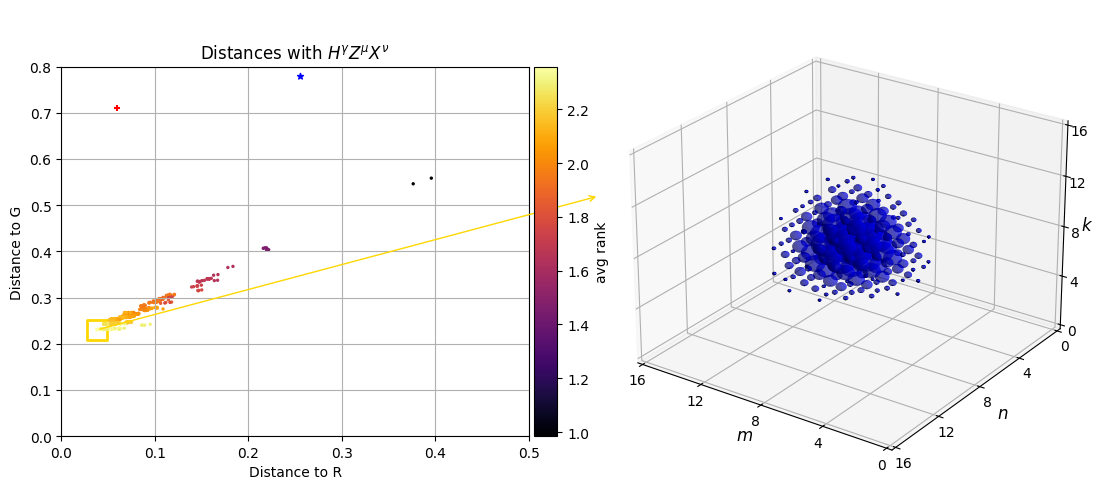

In [29]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances with $H^\gamma Z^\mu X^\nu$')
ax.scatter([0.06], [0.71], 20, 'r',marker="+")
ax3d = fig.add_axes([0.85, 0, 1, 1], projection='3d')
ax3d.set_xticks([])
ax3d.set_yticks([])
ax3d.set_zticks([])

light = LightSource(0,20)
ax3d.set_xlabel(r'$m$', size=12, labelpad=-5)
ax3d.set_ylabel(r'$n$', size=12, labelpad=-5)
ax3d.set_zlabel(r'$k$', size=12, labelpad=-11)
ax3d.set_xlim(0,n_qubits)
ax3d.set_ylim(0,n_qubits)
ax3d.set_zlim(0,n_qubits)
ax3d.tick_params(axis='both', size=10, pad=-3)
ax3d.set_xticks([0,4,8,12,16])
ax3d.set_yticks([0,4,8,12,16])
ax3d.set_zticks([0,4,8,12,16])
maxQ = np.max(symQfunc)

ax3d.view_init(25, 125)
# ax.text(16, 16, 20, "(b)", fontsize=12)

# Plot symmetric space outline
# verts = [(0, 0, 0), (n_qubits, n_qubits, 0), (0, n_qubits, n_qubits), (n_qubits, 0, n_qubits)]
# faces = [[0, 1, 2], [0, 2, 3], [0, 1, 3], [1, 2, 3]]
# poly3d = [[verts[vert_id] for vert_id in face] for face in faces]# draw vertex
# collection = Poly3DCollection(poly3d, edgecolors= 'k', facecolor= [0, 0, 0], linewidths=1, alpha=0.2)
# ax.add_collection3d(collection)

for (i,j,k) in zip(x,y,z):
    r = symQfunc[i,j,k] / maxQ
    if r > 0.1:
        u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:50j]
        s_x = r*np.cos(u)*np.sin(v)
        s_y = r*np.sin(u)*np.sin(v)
        s_z = r*np.cos(v)

        ax3d.plot_surface(s_x+i, s_y+j, s_z+k, color = 'b', alpha=0.5)

ax.scatter([0.038], [0.23], s=200, facecolors='none', edgecolors='gold', linewidths=2, marker="s")
ax.annotate("",
            xy=(1.15, 0.65), xycoords='axes fraction',
            xytext=(0.038, 0.23), textcoords='data',
            arrowprops=dict(arrowstyle="->", color='gold'))
ax.scatter([0.255], [0.78], 20, 'b',marker="*")
scatter_plot = ax.scatter(np.sqrt(clif_max_R_dist), np.sqrt(clif_max_G_dist), 2, c=avg_rank, cmap='inferno')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(scatter_plot, cax=cax, orientation='vertical', label=r'avg rank')
ax.set_xlabel("Distance to R")
ax.set_ylabel("Distance to G")
ax.set_xlim(0,xlim)
ax.set_ylim(0,ylim)
ax.set_xticks(np.arange(0,xlim+0.1,step=0.1))
ax.set_yticks(np.arange(0,ylim+0.1,step=0.1))
ax.grid()

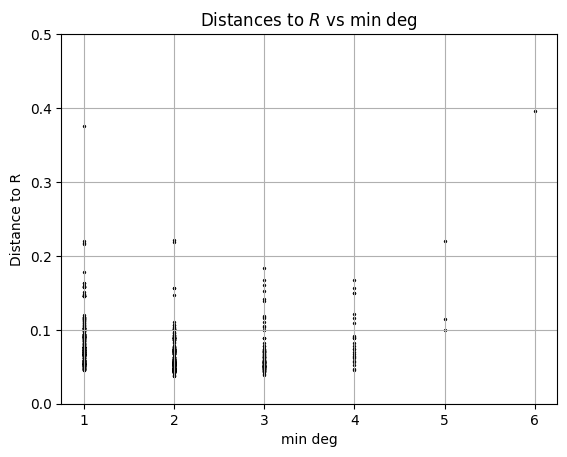

In [10]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances to $R$ vs min deg')
ax.scatter(min_deg, np.sqrt(clif_max_R_dist), 2, 'k')
ax.set_xlabel("min deg")
ax.set_ylabel("Distance to R")
ax.set_ylim(0,xlim)
ax.set_yticks(np.arange(0,xlim+0.1,step=0.1))
ax.grid()

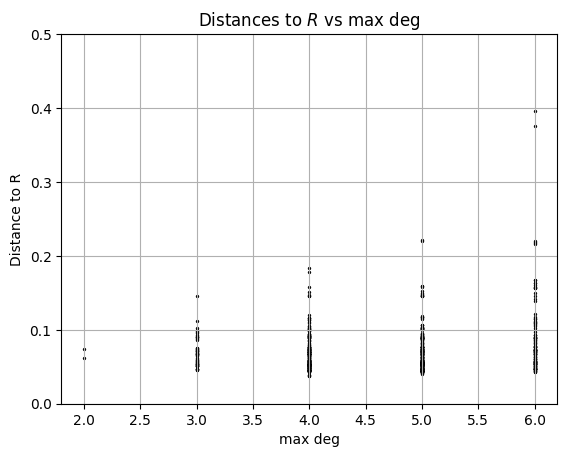

In [11]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances to $R$ vs max deg')
ax.scatter(max_deg, np.sqrt(clif_max_R_dist), 2, 'k')
ax.set_xlabel("max deg")
ax.set_ylabel("Distance to R")
ax.set_ylim(0,xlim)
ax.set_yticks(np.arange(0,xlim+0.1,step=0.1))
ax.grid()

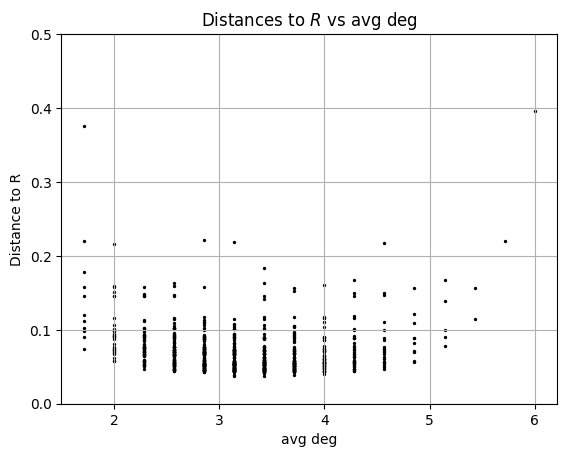

In [12]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances to $R$ vs avg deg')
ax.scatter(avg_deg, np.sqrt(clif_max_R_dist), 2, 'k')
ax.set_xlabel("avg deg")
ax.set_ylabel("Distance to R")
ax.set_ylim(0,xlim)
ax.set_yticks(np.arange(0,xlim+0.1,step=0.1))
ax.grid()

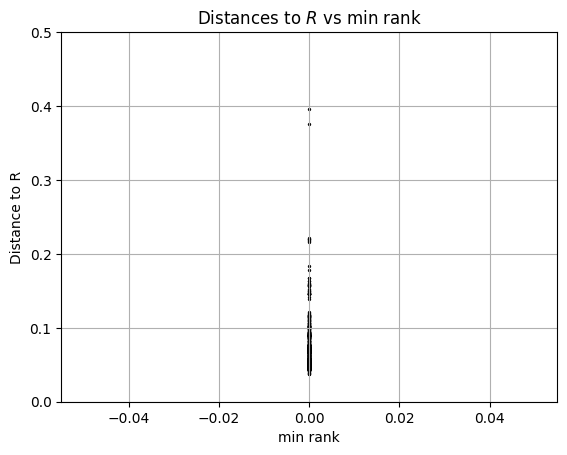

In [13]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances to $R$ vs min rank')
ax.scatter(min_rank, np.sqrt(clif_max_R_dist), 2, 'k')
ax.set_xlabel("min rank")
ax.set_ylabel("Distance to R")
ax.set_ylim(0,xlim)
ax.set_yticks(np.arange(0,xlim+0.1,step=0.1))
ax.grid()

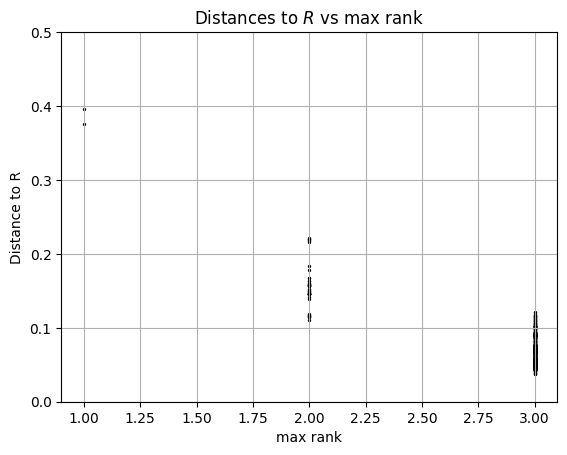

In [14]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances to $R$ vs max rank')
ax.scatter(max_rank, np.sqrt(clif_max_R_dist), 2, 'k')
ax.set_xlabel("max rank")
ax.set_ylabel("Distance to R")
ax.set_ylim(0,xlim)
ax.set_yticks(np.arange(0,xlim+0.1,step=0.1))
ax.grid()

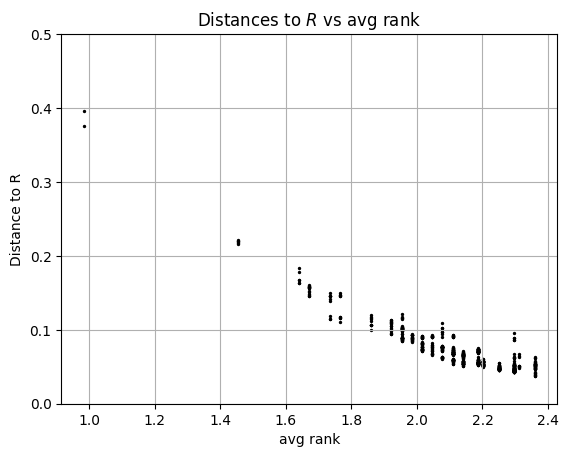

In [15]:
fig = plt.figure(6753)
ax = fig.subplots()
ax.set_title(r'Distances to $R$ vs avg rank')
ax.scatter(avg_rank, np.sqrt(clif_max_R_dist), 2, 'k')
ax.set_xlabel("avg rank")
ax.set_ylabel("Distance to R")
ax.set_ylim(0,xlim)
ax.set_yticks(np.arange(0,xlim+0.1,step=0.1))
ax.grid()